# KNN Classification Tutorial (Real-World Style Dataset)

This notebook trains and evaluates a **K-Nearest Neighbors (KNN)** classifier on a synthetic but realistic customer dataset.

**Columns**
- `Age` (years)
- `Annual_Income` (USD)
- `Spending_Score` (1–100)
- `Visits_Per_Month` (store visits)
- `Customer_Segment` (High-Value, Mid-Value, Low-Value)

**What you'll do**
1. Load and preview the data
2. Split into train/test
3. Scale features and encode labels
4. Grid-search best K (and weights, distance metric)
5. Evaluate performance (accuracy, classification report, confusion matrix)
6. Plot accuracy vs. K
7. Make predictions on new samples


In [1]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)


In [2]:
# 2) Load data
CSV_PATH = 'data/knn_realworld_dataset.csv'  # Ensure this CSV is in the same folder
# If you're running elsewhere, update CSV_PATH accordingly.
df = pd.read_csv(CSV_PATH)
df.head()

,Age,Annual_Income,Spending_Score,Visits_Per_Month,Customer_Segment
0,56,31998,90,2,Mid-Value
1,46,68020,13,4,Mid-Value
2,32,52247,62,2,Mid-Value
3,60,52113,82,8,Mid-Value
4,25,55316,89,8,Mid-Value


### Quick data checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               400 non-null    int64 
 1   Annual_Income     400 non-null    int64 
 2   Spending_Score    400 non-null    int64 
 3   Visits_Per_Month  400 non-null    int64 
 4   Customer_Segment  400 non-null    object
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()

,Age,Annual_Income,Spending_Score,Visits_Per_Month
count,400.000000,400.000000,400.000000,400.000000
mean,41.297500,50357.552500,50.510000,7.842500
std,13.421973,16070.778437,29.128355,2.890256
min,18.000000,-461.000000,1.000000,1.000000
25%,30.000000,39473.500000,25.750000,6.000000
50%,42.000000,50840.500000,50.500000,8.000000
75%,52.000000,61608.250000,76.500000,10.000000
max,64.000000,97805.000000,100.000000,18.000000


### Optional: Simple distributions (one plot at a time)

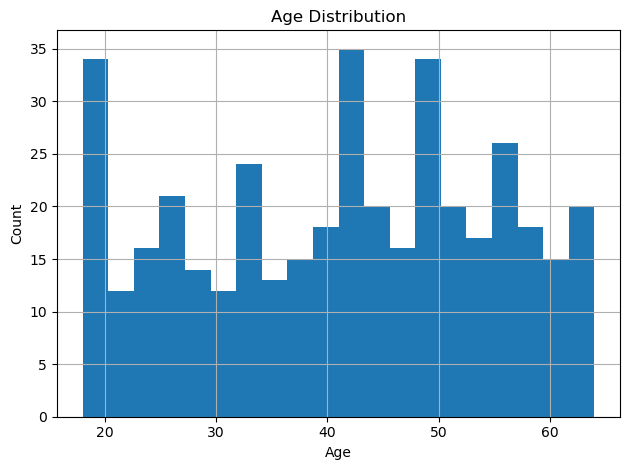

In [5]:
plt.figure()
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()


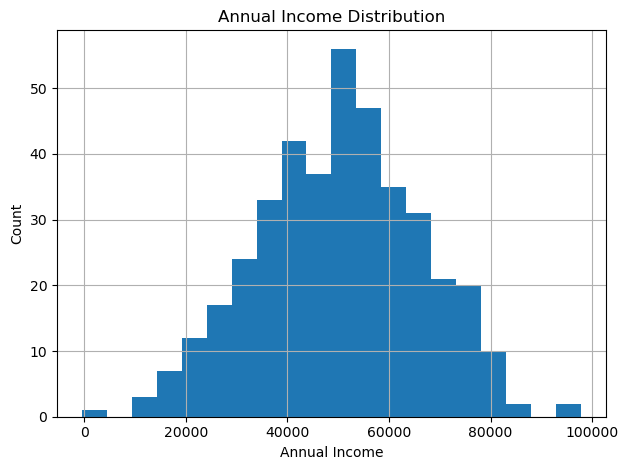

In [6]:
plt.figure()
df['Annual_Income'].hist(bins=20)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.tight_layout()


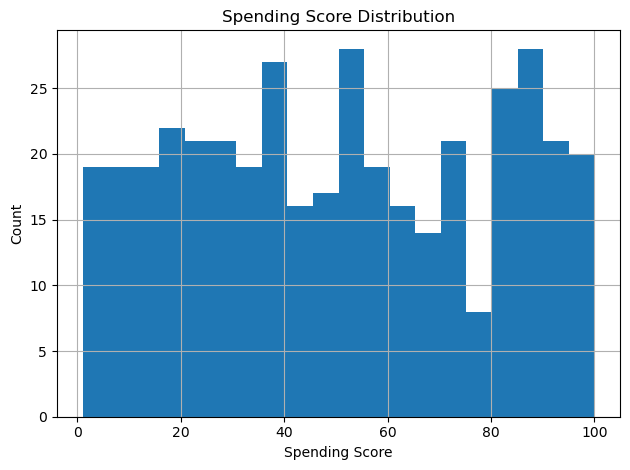

In [7]:
plt.figure()
df['Spending_Score'].hist(bins=20)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.tight_layout()


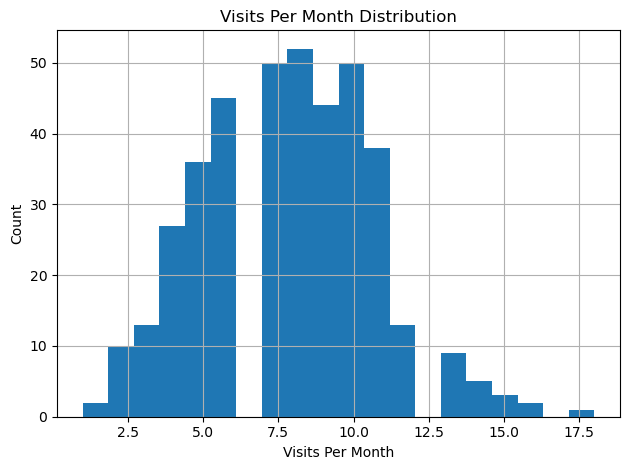

In [8]:
plt.figure()
df['Visits_Per_Month'].hist(bins=20)
plt.title('Visits Per Month Distribution')
plt.xlabel('Visits Per Month')
plt.ylabel('Count')
plt.tight_layout()


## Train/Test Split, Scaling, and Label Encoding

In [9]:
X = df[['Age', 'Annual_Income', 'Spending_Score', 'Visits_Per_Month']].values
y = df['Customer_Segment'].values

# Encode string labels -> integers
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
X_train.shape, X_test.shape

((320, 4), (80, 4))

## Pipeline and Hyperparameter Search (GridSearchCV)

In [10]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],  # Manhattan vs Euclidean
}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'knn__n_neighbors': 4, 'knn__p': 1, 'knn__weights': 'uniform'},
 np.float64(0.9125))

## Evaluation on Test Set

In [11]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df

Test Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

  High-Value       1.00      0.33      0.50         6
   Low-Value       0.80      1.00      0.89         8
   Mid-Value       0.94      0.97      0.96        66

    accuracy                           0.93        80
   macro avg       0.91      0.77      0.78        80
weighted avg       0.93      0.93      0.91        80



,High-Value,Low-Value,Mid-Value
High-Value,2,0,4
Low-Value,0,8,0
Mid-Value,0,2,64


## Accuracy vs K Plot
We lock the best `weights` and `p`, then check accuracy across K.

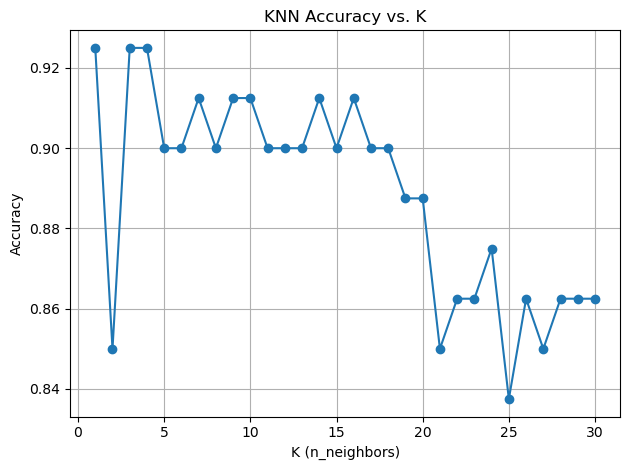

In [12]:
best_weights = grid.best_params_['knn__weights']
best_p = grid.best_params_['knn__p']

k_values = list(range(1, 31))
scores = []

for k in k_values:
    temp_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights=best_weights, p=best_p))
    ])
    temp_pipe.fit(X_train, y_train)
    y_val_pred = temp_pipe.predict(X_test)
    scores.append(accuracy_score(y_test, y_val_pred))

plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title('KNN Accuracy vs. K')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()


## Predict on New Samples

In [13]:
# Example new customers: [Age, Annual_Income, Spending_Score, Visits_Per_Month]
new_X = np.array([
    [28, 38000, 25, 3],
    [45, 82000, 78, 12]
])

pred_enc = best_model.predict(new_X)
pred_labels = le.inverse_transform(pred_enc)
list(pred_labels)

['Low-Value', 'High-Value']

### Notes
- For **regression**, switch to `KNeighborsRegressor` and evaluate with RMSE/MAE.
- If you add categorical features, one-hot encode them before scaling.
- Use stratified splits for classification to preserve class balance.